## Prerequisites
#### Split the `data` folder into `train` and `test` and save it to the **`dataset`** folder.

In [2]:
import os
os.getcwd()

'/Users/samyamoyrakshit/Documents/Replicating-Papers-On-CustomData/ViT'

In [3]:
from utils.split_dataset import DatasetSplitter

splitter = DatasetSplitter(source_dir="../data", target_base="../dataset", split_ratio=0.8)
splitter.split()

Skipping split: '../dataset' already exists and is not empty.


In [4]:
from pathlib import Path

dataset_path = Path("../dataset")
data_root = Path("../data")

total_data = 0
total_train_count=0
total_test_count=0
for folder in sorted(data_root.iterdir()):
    if folder.is_dir():
        folder_name = folder.name
        data_count = len([f for f in folder.rglob("*") if f.is_file()])

        train_folder = dataset_path / "train" / folder_name
        test_folder = dataset_path / "test" / folder_name
        
        train_count = len([f for f in train_folder.rglob("*") if f.is_file()]) if train_folder.exists() else 0
        test_count = len([f for f in test_folder.rglob("*") if f.is_file()]) if test_folder.exists() else 0
        
        match = "✅" if data_count == train_count + test_count else "❌"
        print(f"{folder_name}: data={data_count}, train={train_count}, test={test_count} → {match}")
        total_data += data_count
        total_train_count+=train_count
        total_test_count+=test_count
total_match = "✅" if total_data == total_train_count + total_test_count else "❌"
print(f"\nTotal Data: {total_data} = Total Train Data({total_train_count}) + Total Test Data({total_test_count}) → {total_match}")

Jor Bangla Temple Final: data=308, train=246, test=62 → ✅
Jor Mandir Final: data=212, train=169, test=43 → ✅
Kalachand Temple Final: data=126, train=100, test=26 → ✅
Madan Mohan Temple Final: data=167, train=133, test=34 → ✅
Nandalal Temple Final: data=142, train=113, test=29 → ✅
Radha Gobinda Temple Final: data=149, train=119, test=30 → ✅
Radha Madhab Temple Final: data=139, train=111, test=28 → ✅
Radha Shyam Temple Final: data=182, train=145, test=37 → ✅
Rasmancha Final: data=194, train=155, test=39 → ✅
Shyam Rai Temple Final: data=316, train=252, test=64 → ✅

Total Data: 1935 = Total Train Data(1543) + Total Test Data(392) → ✅


## 0. Get setup

In [59]:
import torch
import torchvision
import torchinfo

import matplotlib.pyplot as plt
from pathlib import Path
import logging

from torch import nn
from torchvision import transforms

from torchinfo import summary

from utils import data_setup, engine
from utils.helper_functions import set_seeds, plot_loss_curves

In [6]:
# Setup device agnostic code
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

## 1. Get `train` and `test` path

In [7]:
image_path = Path("../dataset")
train_dir = image_path/"train"
test_dir = image_path/"test"

In [8]:
train_dir, test_dir

(PosixPath('../dataset/train'), PosixPath('../dataset/test'))

## 2. Create Datasets and DataLoaders

In Table 3, the training resolution is mentioned as being 224 (height=224, width=224).

<img src="markdown_images/table_3.png" width="900" alt="Table 3 from the Vision Transformer paper showing the image size and batch size"/>

<!-- <img src="https://github.com/SamyamoyRakshit/Replicating-Papers-On-CustomData/blob/replications/vit/ViT/markdown_images/table_3.png?raw=true" width="900" alt="Table 3 from the Vision Transformer paper showing the image size and batch size"/> -->

### 2.1 Prepare transforms for images

In [9]:
# Create image size
IMG_SIZE = 224 # comes from Table 3 of ViT paper

# Create a transforms pipeline
manual_transform = transforms.Compose([
    transforms.Resize(size=(IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor()
])
print(f"Manually created transforms: {manual_transform}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


### 2.2 Turn images into `DataLoader`'s

In [10]:
# Create a batch size of 32 (the paper uses 4096 as batch_size but this may be too big for our smaller hardware... can always scale up later)
BATCH_SIZE = 32

# Create Dataloaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transform,
    batch_size=BATCH_SIZE,
    num_workers=4
)
len(train_dataloader), len(test_dataloader), class_names

(49,
 13,
 ['Jor Bangla Temple Final',
  'Jor Mandir Final',
  'Kalachand Temple Final',
  'Madan Mohan Temple Final',
  'Nandalal Temple Final',
  'Radha Gobinda Temple Final',
  'Radha Madhab Temple Final',
  'Radha Shyam Temple Final',
  'Rasmancha Final',
  'Shyam Rai Temple Final'])

In [11]:
len(class_names)

10

### 2.3 Visualize a Single image

In [12]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))
print(f"image_batch shape: {image_batch.shape}") 
print(f"length of label batch: {len(label_batch)}")

# Get a single image and label from the batch
image, label = image_batch[0], label_batch[0]

# View single image and label shapes
image.shape, label

image_batch shape: torch.Size([32, 3, 224, 224])
length of label batch: 32


(torch.Size([3, 224, 224]), tensor(6))

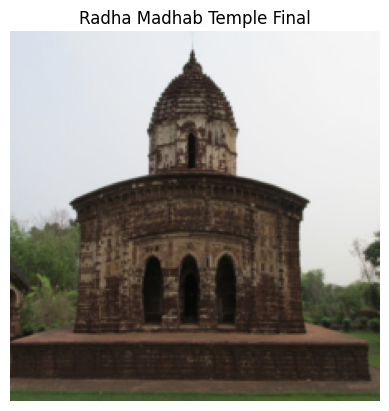

In [13]:
# Plot the image with matplotlib
plt.imshow(image.permute(1,2,0)) # (C,H,W) => (H,W,C)
plt.title(class_names[label])
plt.axis(False);

## 3. Equation 1: Split data into patches and creating the class, position and patch embedding


<img src="markdown_images/ViT_table_1.jpeg" width=600 alt="MLP Head">

<br>

$$
\begin{aligned}
\textbf{Input Shape: } & H, W, C = 224 \times 224 \times 3 \\
P &= 16 \\
P^2 &= 16 \times 16 \\
N &= \frac{H \times W}{P^2} = \frac{224 \times 224}{16 \times 16} = 14 \times 14 = 196 \\
C &= 3 \\
\textbf{Output Shape: Flattened 2D patches} & = \big(N, \; (P^2 \times C)\big) = \big(196, \; (16 \times 16 \times 3)\big) = \mathbf{(196, 768)} \\
\text{D: Constant latent vector size} & = \text{Embedding dimension (see Table 1)} \\
& \text{Here, } \quad D = (P^2 \times C) = 768
\end{aligned}
$$

<br>

```Python
# Equation 1
x_input = [class_token, image_patch_1, image_patch_2, ... image_patch_N] +
[class_token_pos, image_patch_1_pos, image_patch_2_pos, ... image_patch_N_pos]
```

### 3.1 Calculating patch embedding input and output shapes by hand

In [14]:
# Create example values
height = 224
width = 224
color_channels = 3
patch_size = 16

#Calculate the number of patches
number_of_patches = int((height*width) / patch_size**2)
number_of_patches

196

In [15]:
# Input Shape
embedding_layer_input_shape = (height, width, color_channels)

# Output Shape
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

print(f"Input Shape (single 2D image): {embedding_layer_input_shape}")
print(f"Output Shape (single 1D sequence of patches): {embedding_layer_output_shape} -> (number_of_patches, embedding_dimension)")

Input Shape (single 2D image): (224, 224, 3)
Output Shape (single 1D sequence of patches): (196, 768) -> (number_of_patches, embedding_dimension)


### 3.2 Turning a single image into patches

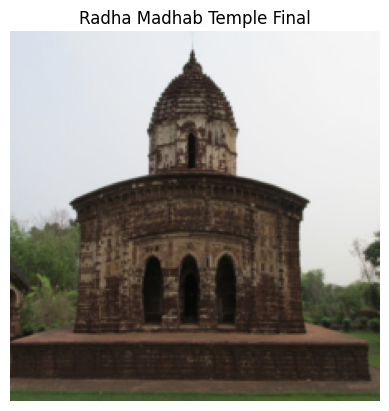

In [16]:
# View a single image
plt.imshow(image.permute(1, 2, 0)) # (C,H,W) => (H,W,C); adjust for matplotlib
plt.title(class_names[label])
plt.axis(False);

In [17]:
image.shape

torch.Size([3, 224, 224])

Shape of the image: torch.Size([16, 224, 3])


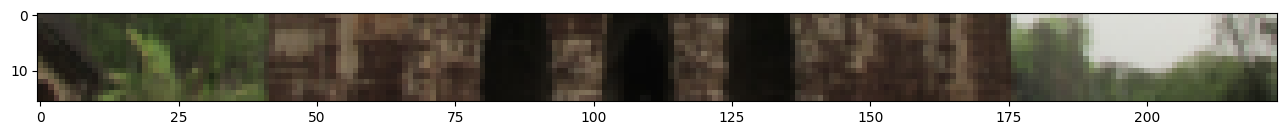

In [18]:
# Get the 10th row of the image
image_permuted = image.permute(1,2,0) # (C,H,W) => (H,W,C)

# Index to plot the top row of the pixels (16x224x3)
patch_size = 16

row_num = 10  # 10th patch row (1-indexed)
start = (row_num - 1) * patch_size
end = start + patch_size

plt.figure(figsize = (patch_size, patch_size))
print(f"Shape of the image: {image_permuted[start:end, :, :].shape}")
plt.imshow(image_permuted[start:end, :, :]);

Number of patches per row: 14
Patch size: 16 pixels x 16 pixels


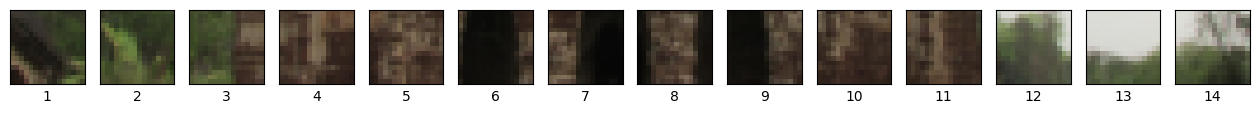

In [19]:
# Setup code to plot 10th row as patches
img_size = 224
patch_size = 16
num_patches = img_size // patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size."
print(f"Number of patches per row: {num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

# Craete a series of subplots
fig, axs = plt.subplots(nrows=1,
                        ncols=img_size // patch_size,
                        sharex=True,
                        sharey=True,
                        figsize=(patch_size,patch_size))

row_num = 10
# Iterate through no. of patches in the row
for i, patch in enumerate(range(0, img_size, patch_size)):
    axs[i].imshow(image_permuted[((row_num - 1) * patch_size):((row_num - 1) * patch_size)+patch_size, patch:patch+patch_size, :]);
    axs[i].set_xlabel(i+1) # set the label
    axs[i].set_xticks([])
    axs[i].set_yticks([])

Number of patches per row: 14      
Number of patches per column: 14      
Total patches: 196      
Patch size: 16 pixels x 16 pixels


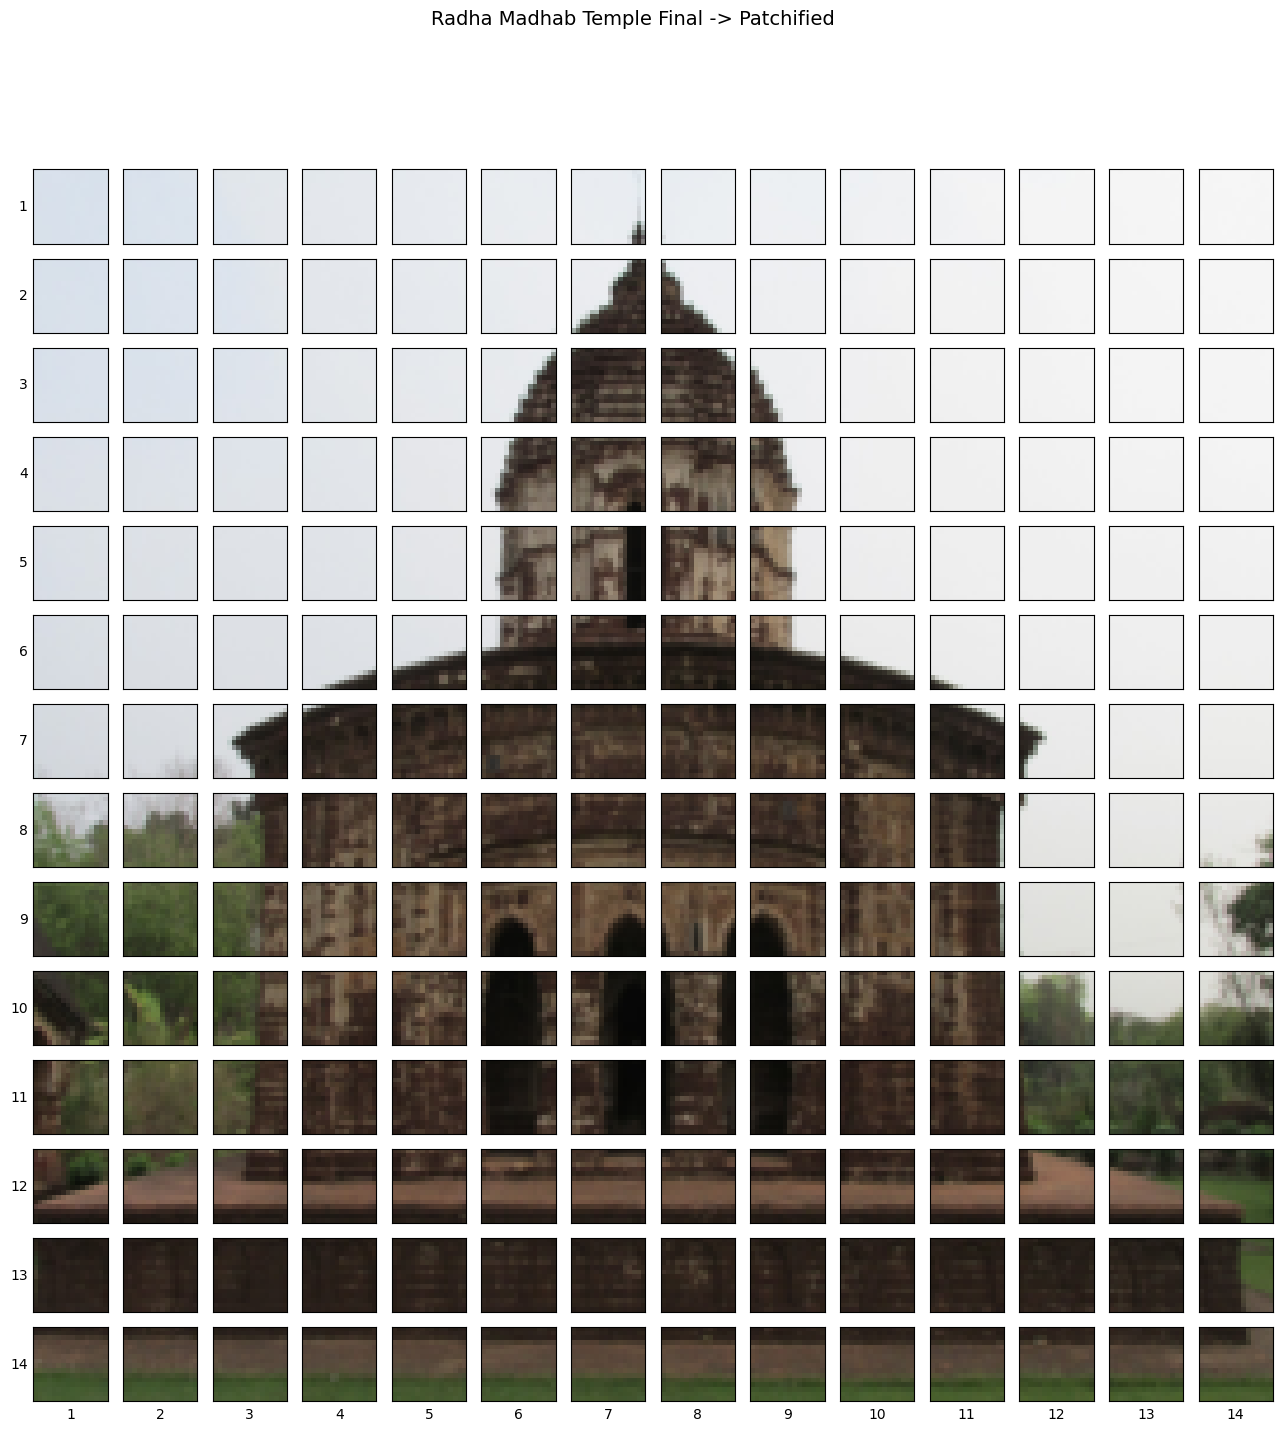

In [20]:
#Setup up code to plot whole image as patches
img_size=224
patch_size = 16
num_patches = img_size // patch_size
if img_size % patch_size != 0:
    raise ValueError(f"Image size ({img_size}) must be divisible by patch size ({patch_size}).")

print(f"Number of patches per row: {num_patches}\
      \nNumber of patches per column: {num_patches}\
      \nTotal patches: {num_patches*num_patches}\
      \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows = img_size // patch_size,
                        ncols = img_size // patch_size,
                        figsize = (patch_size,patch_size),
                        sharex = True,
                        sharey = True)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, img_size, patch_size)):   # iterate through height
    for j, patch_width in enumerate(range(0, img_size, patch_size)):  # iterate through width
        # Plot the permuted image on different axes
        axs[i,j].imshow(image_permuted[patch_height:patch_height+patch_size,  # iterate through height
                                       patch_width:patch_width+patch_size,  # iterate through width
                                       :]) # get all the color channel
        
        # # Set up label information for each subplot (patch), remove the ticks for clarity and set labels to outside
        axs[i,j].set_ylabel(i+1,
                            rotation="horizontal", # Makes the label text horizontal instead of vertical.
                            horizontalalignment="right",  # Aligns the label text to the right edge of its position.
                            verticalalignment="center") # Centers it vertically relative to the axis.
        axs[i,j].set_xlabel(j+1)
        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])
        axs[i,j].label_outer() # Makes only the labels on the outermost subplots visible. This avoids duplicate labels in every subplot.

# Set up a title for the plot
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=14)
plt.show()

### 3.3 Creating image patches and turning them into patch embeddings
Perhaps we could craete the image patches and image patch embeddings in a single step using `torch.nn.Conv2d()` and setting kernel size and stride parameters to `patch_size`.

$$
\begin{aligned}
\text{Output size} &= \left\lfloor \frac{n + 2p - f}{s} + 1 \right\rfloor \\
\text{where:} \quad
n & = \text{ input image size (height or width)}, \\
f & = \text{ filter/kernel size}, \\
p & = \text{ padding}, \\
s & = \text{ stride}.
\end{aligned}
$$

In [21]:
# Calculate output image shape for 224x224 image shape
import numpy as np
n = 224
p = 0
s=16
f=16
op_shape = np.floor(((n+2*p-f)/s)+1)
op_shape

np.float64(14.0)

In [22]:
# Create conv2d layer to turn image into patches of learnable faeture maps(embeddings)
from torch import nn

# Set the patch size 
patch_size = 16

# Create a conv2d layer with hyperparameters from the ViT paper
conv2d = nn.Conv2d(in_channels=3, # for color images
                   out_channels=768, # D size from Table 1 for ViT-Base
                   kernel_size=patch_size,
                   stride=patch_size,
                   padding=0)
conv2d

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))

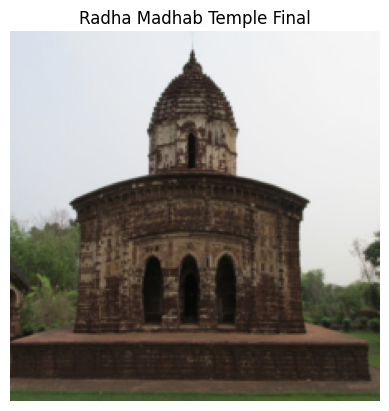

In [23]:
# View single image
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False);

In [24]:
# Pass the image through the convolutional layer
image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension -> (batch_size, color_size, height, width)
print(image.shape)
print(image_out_of_conv.shape)

torch.Size([3, 224, 224])
torch.Size([1, 768, 14, 14])


Now we've passed a single image to our `conv2d` layer, its shape is:

```python
torch.Size([1, 768, 14, 14]) # [batch_size, embedding_dim, feature_map_height, feature_map_width]
```

Showing random convolutional feature maps from indexes: [9, 748, 702, 591, 312]
torch.Size([1, 14, 14])


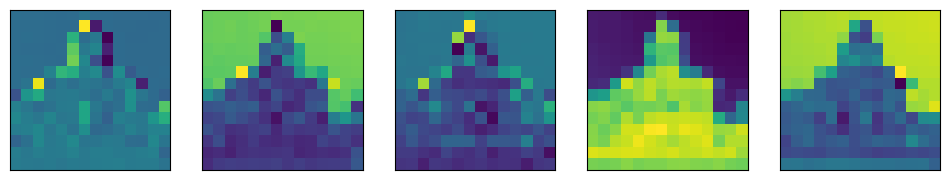

In [25]:
# plot random convolutional feature maps (embeddings)
import random
random_indexes = random.sample(range(0, 758), k=5) # pick 5 random images
print(f"Showing random convolutional feature maps from indexes: {random_indexes}")

# Create plot
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12,12))

# Plot random image feature maps
for i,idx in enumerate(random_indexes):
    image_conv_feature_map = image_out_of_conv[:, idx, :, :] # index on the output tensor of conv2d layer
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy()) # remove batch dimension, and remove from grad tracking / switch to numpy for matplotib
    axs[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

print(image_conv_feature_map.shape)

In [26]:
# Get a single feature map in tensor form
single_feature_map = image_out_of_conv[:, 0, :, :]
single_feature_map.requires_grad, single_feature_map.shape, single_feature_map

(True,
 torch.Size([1, 14, 14]),
 tensor([[[-0.2124, -0.2158, -0.2150, -0.2153, -0.2158, -0.2143, -0.3022,
           -0.2178, -0.2167, -0.2177, -0.2197, -0.2203, -0.2233, -0.2210],
          [-0.2129, -0.2127, -0.2167, -0.2135, -0.2146, -0.2157, -0.3915,
            0.0700, -0.2190, -0.2194, -0.2201, -0.2193, -0.2215, -0.2231],
          [-0.2112, -0.2095, -0.2135, -0.2144, -0.2123, -0.2077,  0.0070,
           -0.1541,  0.0035, -0.2220, -0.2181, -0.2193, -0.2213, -0.2215],
          [-0.2084, -0.2086, -0.2086, -0.2121, -0.2134, -0.4630, -0.0430,
           -0.1851,  0.0561, -0.2196, -0.2181, -0.2190, -0.2210, -0.2203],
          [-0.2110, -0.2080, -0.2120, -0.2101, -0.2099, -0.5505, -0.0070,
           -0.0973,  0.0227, -0.2161, -0.2161, -0.2177, -0.2175, -0.2200],
          [-0.2052, -0.2080, -0.2081, -0.3246, -0.1781, -0.2223, -0.0182,
            0.0269,  0.0072, -0.2616, -0.2144, -0.2161, -0.2174, -0.2173],
          [-0.2036, -0.2198, -0.3129, -0.0619, -0.0157, -0.0480, -0.1028,

### 3.4 Flattening the patch embedding with `torch.nn.Flatten()`

Right now we've a series of convolutional feature maps (patch embeddings) that we want to flatten into a sequence of patch embeddings to satisfy the input criteria of the ViT Transformer Encoder.

In [27]:
print(f"{image_out_of_conv.shape} -> (batch_size, embedding_dim, feature_map_height, feature_map_width)")

torch.Size([1, 768, 14, 14]) -> (batch_size, embedding_dim, feature_map_height, feature_map_width)


Want: (batch_size, number_of_patches, embedding_dim)

In [28]:
flatten_layer = nn.Flatten(start_dim=2,  # flatten feature_map_height (dimension 2), [1, 768, 14, 14] dimensions -> [0,1,2,3] 
                           end_dim=3) # flatten feature_map_width (dimension 3), [1, 768, 14, 14] dimensions -> [0,1,2,3]

flatten_layer(image_out_of_conv).shape

torch.Size([1, 768, 196])

Original image shape: torch.Size([3, 224, 224])
Image feature map (patches) shape: torch.Size([1, 768, 14, 14])
Flattened image feature map shape: torch.Size([1, 768, 196])


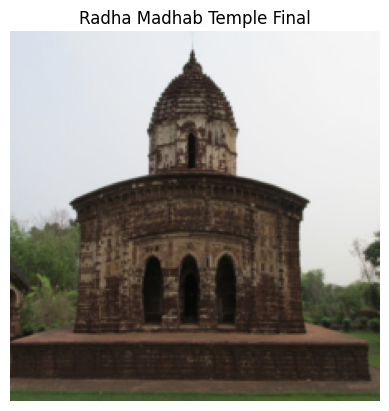

In [29]:
# Put everything together
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)
print(f"Original image shape: {image.shape}")

# Turn image into feature maps
image_out_of_conv = conv2d(image.unsqueeze(0))  # add batch dimension
print(f"Image feature map (patches) shape: {image_out_of_conv.shape}")

# Flatten the feature maps
image_out_of_conv_flattened = flatten_layer(image_out_of_conv)
print(f"Flattened image feature map shape: {image_out_of_conv_flattened.shape}")

In [30]:
# Rearrange output of flattened layer
image_out_of_conv_flattened_permuted = image_out_of_conv_flattened.permute(0,2,1)
print(f"{image_out_of_conv_flattened_permuted.shape} -> [batch_size, number_of_patches, embedding_dim]")

torch.Size([1, 196, 768]) -> [batch_size, number_of_patches, embedding_dim]


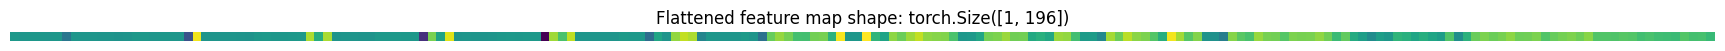

In [31]:
# Get a single flattened feature map
single_flattened_feature_map = image_out_of_conv_flattened_permuted[:,:,0] # Get the 1st embedding_dim (0th index)

# Plot the flattened feature map visually
plt.figure(figsize=(22,22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"Flattened feature map shape: {single_flattened_feature_map.shape}")
plt.axis(False);

### 3.5 Turning the ViT patch embedding layer into a PyTorch module

We want this moule to do a few things:

1. Create class called `PatchEmbedding`, that inherits from `nn.Module`.

2. Initialize appropriate hyperparameters, such as channels, embedding dimension, patch size. 

3. Create a layer to turn an image into embedded patches using `nn.Conv2d()`.

4. Create a layer to flatten the feature maps of the output of the layer in step 3.

5. Define a `forward()` that defines the forward computation (e.g. pass through layer from 3 and 4).

6. Make sure the output shape of the layer reflects the required output shape of the patch embedding.

In [32]:
# 1. Craete a class called PatchEmbedding
class PatchEmbedding(nn.Module):
    # 2. Initialize the layer with appropriate hyperparameters
    def __init__(self,
                in_channels:int=3,
                patch_size:int=16,
                embedding_dim:int=768): # from Table 1 for ViT-Base
        super().__init__()

        self.patch_size = patch_size
        # 3. Create a layer to turn an image into embedded patches
        self.patcher = nn.Conv2d(in_channels=in_channels,
                                 out_channels=embedding_dim,
                                 kernel_size=patch_size,
                                 stride=patch_size,
                                 padding=0)
        
        # 4. Create a layer to flatten feature map outputs of Conv2d
        self.flatten = nn.Flatten(start_dim=2,
                                  end_dim=3)
        
    # 5. Define a forward method to define the forward computation steps
    def forward(self, x):
        # Create assertion to check that inputs are the correct shape
        image_resolution = x.shape[-1]
        assert image_resolution % patch_size == 0, f"Input image size must be divisible by patch size, image shape: {image_resolution}, patch size: {patch_size}"

        # Perform the forward pass 
        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched)
        # 6. Make the returned sequence embedding dimensions are in the right order (batch_size, number_of_patches, embedding_dimension)
        return x_flattened.permute(0,2,1)

In [33]:
set_seeds()

# Create an instance of patch embedding layer
patchify = PatchEmbedding(in_channels=3,
                          patch_size=16,
                          embedding_dim=768)

# Pass a single image through patch embedding layer
print(f"Input image size: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0)) # add an extra batch dimension
print(f"Output patch embedding sequence shape: {patch_embedded_image.shape}")

Input image size: torch.Size([1, 3, 224, 224])
Output patch embedding sequence shape: torch.Size([1, 196, 768])


In [34]:
# make sure assertion works
rand_image_tensor = torch.randn(1,3,224,224)
rand_image_tensor_bad = torch.randn(1,3,250,250)
# patchify(rand_image_tensor_bad)

### 3.6 Craeting the class token embdding

<b>Want to: `prepand`(add to the first (opposite of 'append')) a learnable class token to the start of the patch embedding.</b>

<img src="markdown_images/add_cls_token.png" width=900 alt="Class Token">

In [35]:
patch_embedded_image

tensor([[[-0.9092,  0.2575, -0.2675,  ...,  0.7044, -0.4063,  0.3166],
         [-0.9182,  0.2618, -0.2711,  ...,  0.7137, -0.4092,  0.3158],
         [-0.9351,  0.2626, -0.2622,  ...,  0.7264, -0.4223,  0.3157],
         ...,
         [-0.3341,  0.0675, -0.1141,  ...,  0.1831, -0.0732,  0.1036],
         [-0.3331,  0.0481, -0.1207,  ...,  0.1843, -0.0676,  0.0909],
         [-0.3826,  0.1276, -0.1206,  ...,  0.1735, -0.0926,  0.0747]]],
       grad_fn=<PermuteBackward0>)

In [36]:
# Get the batch size and embedding dimension
batch_size = patch_embedded_image.shape[0]
embedding_dimension = patch_embedded_image.shape[-1]
batch_size, embedding_dimension

(1, 768)

In [37]:
# Create the class token embedding as a learnable parameter that shares the same size as the embedding dimension (D)
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension),
                           requires_grad=True)

class_token.shape

torch.Size([1, 1, 768])

In [38]:
patch_embedded_image.shape

torch.Size([1, 196, 768])

In [39]:
# Add the class token embedding to the front of the patch embedding
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image),
                                                      dim=1) # number_of_patches dimension

# Print the sequence of patch embeddings with the prepended class token embedding
print(patch_embedded_image_with_class_embedding)
print(f"Sequence of patch embeddings with class token prepended shape: {patch_embedded_image_with_class_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.9092,  0.2575, -0.2675,  ...,  0.7044, -0.4063,  0.3166],
         [-0.9182,  0.2618, -0.2711,  ...,  0.7137, -0.4092,  0.3158],
         ...,
         [-0.3341,  0.0675, -0.1141,  ...,  0.1831, -0.0732,  0.1036],
         [-0.3331,  0.0481, -0.1207,  ...,  0.1843, -0.0676,  0.0909],
         [-0.3826,  0.1276, -0.1206,  ...,  0.1735, -0.0926,  0.0747]]],
       grad_fn=<CatBackward0>)
Sequence of patch embeddings with class token prepended shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


### 3.7 Craeting the position embedding

**Want to: create a series of 1D learnable positon embeddings and to add them to the sequence of patch embeddings.**

<img src="markdown_images/pos_embedding.png" width=900 alt="Position Embedding">

In [40]:
# Calculate N (number_of_patches)
number_of_patches = int((height*width) / patch_size**2)

# Get the embedding dimension
embedding_dimension = patch_embedded_image_with_class_embedding.shape[-1]

# Get the batch size
batch_size = patch_embedded_image_with_class_embedding.shape[0]

# Create the learnable 1D position embedding
position_embedding = nn.Parameter(torch.ones(batch_size,
                                             number_of_patches+1, # here, (196+1)=197
                                             embedding_dimension,
                                             requires_grad=True))

position_embedding.shape, position_embedding


(torch.Size([1, 197, 768]),
 Parameter containing:
 tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]], requires_grad=True))

In [41]:
# Add the position embedding to the patch and class token embedding
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding
print(f"Patch and position embedding shape: {patch_and_position_embedding.shape}")
print(patch_and_position_embedding)

Patch and position embedding shape: torch.Size([1, 197, 768])
tensor([[[2.0000, 2.0000, 2.0000,  ..., 2.0000, 2.0000, 2.0000],
         [0.0908, 1.2575, 0.7325,  ..., 1.7044, 0.5937, 1.3166],
         [0.0818, 1.2618, 0.7289,  ..., 1.7137, 0.5908, 1.3158],
         ...,
         [0.6659, 1.0675, 0.8859,  ..., 1.1831, 0.9268, 1.1036],
         [0.6669, 1.0481, 0.8793,  ..., 1.1843, 0.9324, 1.0909],
         [0.6174, 1.1276, 0.8794,  ..., 1.1735, 0.9074, 1.0747]]],
       grad_fn=<AddBackward0>)


### 3.8 Putting it all together: from image to embedding

We've written code to turn an image into a flattened sequence of patch embeddings.

$$
\begin{aligned}
\mathbf{z}_{0} &=\left[\mathbf{x}_{\text {class }} ; \mathbf{x}_{p}^{1} \mathbf{E} ; \mathbf{x}_{p}^{2} \mathbf{E} ; \cdots ; \mathbf{x}_{p}^{N} \mathbf{E}\right]+\mathbf{E}_{\text {pos }}, & & \mathbf{E} \in \mathbb{R}^{\left(P^{2} \cdot C\right) \times D}, \mathbf{E}_{\text {pos }} \in \mathbb{R}^{(N+1) \times D}
\end{aligned}
$$

Now let's it all in one sell.

In [42]:
# Set seeds
set_seeds()

# 1. Set the patch size
patch_size = 16

# 2. Print shapes of the original image tensor and get the image dimensions
print(f"Image tensor shape: {image.shape}")
height, width = image.shape[1], image.shape[2]

# 3. Get the image tensor and add a batch dimension
x = image.unsqueeze(0)
print(f"Input image shape: {x.shape}")

# 4. Craete patch embedding layer
patch_embedding_layer = PatchEmbedding(in_channels=3,
                                       patch_size=patch_size,
                                       embedding_dim=768)

# 5. Pass input image through PatchEmbedding
patch_embedding = patch_embedding_layer(x)
print(f"Patch embedding shape: {patch_embedding.shape}")

# 6. Craete class token embedding
batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension),
                           requires_grad=True)
print(f"Class token embedding shape: {class_token.shape}")

# 7. Prepend the class token embedding to patch embedding
patch_embedded_class_token = torch.cat((class_token, patch_embedding), dim=1)
print(f"Patch embedding with class token shape: {patch_embedded_class_token.shape}")

# 8. Create position embedding
number_of_patches = int((height*width) / patch_size**2)
position_embedding = nn.Parameter(torch.ones(batch_size, number_of_patches+1, embedding_dimension),
                                  requires_grad=True)
print(f"Position embedding shape: {position_embedding.shape}")

# 9. Add the position embedding to patch embedding with class token
patch_and_position_embedding = patch_embedded_class_token + position_embedding
print(f"Patch and position embedding shape: {patch_and_position_embedding.shape}")

Image tensor shape: torch.Size([3, 224, 224])
Input image shape: torch.Size([1, 3, 224, 224])
Patch embedding shape: torch.Size([1, 196, 768])
Class token embedding shape: torch.Size([1, 1, 768])
Patch embedding with class token shape: torch.Size([1, 197, 768])
Position embedding shape: torch.Size([1, 197, 768])
Patch and position embedding shape: torch.Size([1, 197, 768])


## 4. Equation 2: Multi-Head Attention (MSA)

$$
\begin{aligned}
\mathbf{z}_{\ell}^{\prime} &=\operatorname{MSA}\left(\operatorname{LN}\left(\mathbf{z}_{\ell-1}\right)\right)+\mathbf{z}_{\ell-1}, & & \ell=1 \ldots L
\end{aligned}
$$


<img src="markdown_images/msa_block.png" width=900 alt="MultiHead Self-Attention Block ">

<br>
<br>

* Multihead self-attention: which part of a sequence should pay the most attention to itself?
    * In our case, we have a series of embedded patches, which patch significantly relates to another patch.
    * We want our neural network (ViT) to learn this relationship/representation.

* `LayerNorm` = Layer Normalization (LayerNorm) is a technique to normalize the distributions of intermediate layers. It enables smoother gradients, faster training, and better generalization accuracy.
    * Normalization = make everything have the same mean and same standard deviation.
    * In PyTorch, [`torch.nn.LayerNorm()`](https://docs.pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html) normalizatiizes the values over $D$ dimension, in our case, the $D$ dimension is the embedding dimension.

In [43]:
class MultiHeadSelfAttentionBlock(nn.Module):
    """Creates a multi-head self-attention block ("MSA block" for short).
    """
    def __init__(self, 
                 embedding_dim:int=768, # Hidden size D (embedding dimension) from Table 1 for ViT-Base
                 num_heads:int=12, # Heads from Table 1 for ViT-Base
                 attn_dropout:int=0):
        super().__init__()

        # Create the norm layer (LN)
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        # Create multihead attention (MSA) layer
        self.multihead_attn = nn.MultiheadAttention(embed_dim=embedding_dim,
                                                    num_heads=num_heads,
                                                    dropout=attn_dropout,
                                                    batch_first=True) # if batch is in first (batch, seq, feature) -> in our case, (batch_size, number_of_patches, embedding_dimension)
    
    # Create a forward() method to pass the data through the layers
    def forward(self, x):
        x = self.layer_norm(x)
        attn_output, _ = self.multihead_attn(query=x, # query embeddings
                                             key=x, # key embeddings
                                             value=x, # value embeddings
                                             need_weights=False) # Here, we don't need the weights; we want just the layer outputs
        return attn_output

In [44]:
# Create an instance of our MSA block
multihead_self_attention_block =MultiHeadSelfAttentionBlock(embedding_dim=768,
                                                            num_heads=12,
                                                            attn_dropout=0)

# Pass the patch and position image embedding sequence through MSA block
patched_image_through_msa_block = multihead_self_attention_block(patch_and_position_embedding)
print(f"Input shape of MSA block: {patch_and_position_embedding.shape}")
print(f"Output shape of MSA block: {patched_image_through_msa_block.shape}")

Input shape of MSA block: torch.Size([1, 197, 768])
Output shape of MSA block: torch.Size([1, 197, 768])


In [60]:
patch_and_position_embedding, patched_image_through_msa_block

(tensor([[[2.0000, 2.0000, 2.0000,  ..., 2.0000, 2.0000, 2.0000],
          [0.0908, 1.2575, 0.7325,  ..., 1.7044, 0.5937, 1.3166],
          [0.0818, 1.2618, 0.7289,  ..., 1.7137, 0.5908, 1.3158],
          ...,
          [0.6659, 1.0675, 0.8859,  ..., 1.1831, 0.9268, 1.1036],
          [0.6669, 1.0481, 0.8793,  ..., 1.1843, 0.9324, 1.0909],
          [0.6174, 1.1276, 0.8794,  ..., 1.1735, 0.9074, 1.0747]]],
        grad_fn=<AddBackward0>),
 tensor([[[-0.2175, -0.2017,  0.0477,  ..., -0.4421,  0.9133, -0.4861],
          [-0.2150, -0.1957,  0.0491,  ..., -0.4392,  0.9191, -0.4965],
          [-0.2150, -0.1958,  0.0490,  ..., -0.4393,  0.9191, -0.4965],
          ...,
          [-0.2149, -0.1949,  0.0464,  ..., -0.4354,  0.9191, -0.4957],
          [-0.2153, -0.1944,  0.0466,  ..., -0.4365,  0.9196, -0.4958],
          [-0.2138, -0.1966,  0.0451,  ..., -0.4370,  0.9177, -0.4963]]],
        grad_fn=<TransposeBackward0>))

## 5. Equation 3: Multilayer Perceptron (MLP Block)

$$
\begin{aligned}
\mathbf{z}_{\ell} &=\operatorname{MLP}\left(\operatorname{LN}\left(\mathbf{z}_{\ell}^{\prime}\right)\right)+\mathbf{z}_{\ell}^{\prime}, & & \ell=1 \ldots L
\end{aligned}
$$

<img src="markdown_images/mlp_block.png" width=900 alt="MultiLayer Perceptron Block ">

* **MLP** = The MLP contains two layers with a `GELU` non-linaerity (section 3.1 from ViT paper).
    * MLP = a quite broad term for a block with a series of layer(s), layers can be multiple or even only one hidden layer.
    * Layers can mean: fully-connceted, dense, linear, feed-forward, all are often similar names for the same thing. In PyTorch, they are often called `torch.nn.Linear()`.
* **Dropout** = Dropout, when used, is applied after every dense layer except for the the qkv-projections and directly after adding positional- to patch embeddings. Hybrid models are trained with the exact setup as their ViT counterparts. (section B.1 of ViT paper)
    * Value for dropout is available in Table3.

In pseudocode:

```python
#MLP
x = layer norm -> linear layer -> non-linear layer -> dropout -> linear layer -> dropout
```

In [46]:
class MLPBlock(nn.Module):
    def __init__(self,
                 embedding_dim:int=768,
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 dropout:float=0.1 # from Table 3 for ViT-Base
                 ):
        super().__init__()

        # Create the Norm Layer (LN)
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        # Create Multi Layer Perceptron (MLP) layer(s)
        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim,
                      out_features=mlp_size),
            nn.GELU(),
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size,
                      out_features=embedding_dim), # take back to embedding_dim
            nn.Dropout(p=dropout)          
        )
    
    def forward(self,x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        return x
        # return self.mlp(self.layer_norm(x)) ## same as above

In [47]:
# Create an instance of MLP Block
mlp_block = MLPBlock(embedding_dim=768,
                     mlp_size=3072,
                     dropout=0.1)

# Pass output the MSABlcok through MLPBlock
patched_image_through_mlp_block = mlp_block(patched_image_through_msa_block)
print(f"Input shape of MLP block: {patched_image_through_msa_block.shape}")
print(f"Output shape of MLP block: {patched_image_through_mlp_block.shape}")

Input shape of MLP block: torch.Size([1, 197, 768])
Output shape of MLP block: torch.Size([1, 197, 768])


In [48]:
patched_image_through_msa_block, patched_image_through_mlp_block

(tensor([[[-0.2175, -0.2017,  0.0477,  ..., -0.4421,  0.9133, -0.4861],
          [-0.2150, -0.1957,  0.0491,  ..., -0.4392,  0.9191, -0.4965],
          [-0.2150, -0.1958,  0.0490,  ..., -0.4393,  0.9191, -0.4965],
          ...,
          [-0.2149, -0.1949,  0.0464,  ..., -0.4354,  0.9191, -0.4957],
          [-0.2153, -0.1944,  0.0466,  ..., -0.4365,  0.9196, -0.4958],
          [-0.2138, -0.1966,  0.0451,  ..., -0.4370,  0.9177, -0.4963]]],
        grad_fn=<TransposeBackward0>),
 tensor([[[-0.0633, -0.0046,  0.2348,  ...,  0.0013, -0.1032,  0.2844],
          [-0.0246,  0.0217,  0.2039,  ..., -0.0000, -0.1429,  0.2464],
          [-0.0560, -0.0590,  0.1513,  ..., -0.0112, -0.2056,  0.3054],
          ...,
          [-0.0389, -0.0851,  0.1635,  ...,  0.0804, -0.1652,  0.1360],
          [-0.0924, -0.0000,  0.1403,  ...,  0.1689, -0.1837,  0.2295],
          [-0.1199, -0.0039,  0.0875,  ...,  0.1158, -0.0345,  0.2596]]],
        grad_fn=<MulBackward0>))

## 6. Creating the Transformer Encoder

The Transformer Encoder is a combination of alternating blocks of MSA (equation 2) and MLP (equation 3).

And there are residual connections between each block.

* Encoder = turn a sequence into learnable representation.
* Decoder = go from learn representation back to some sort of sequence.
* Residual connections = add a layer(s) input to its subsequent output, this enables the creation of deeper networks (prevents weights from getting too small (vanishing gradients problem)).


In pseudocode:
```python
# Transformer Encoder
x_input -> MSA_block -> [MSA_block_output + x_input] -> MLP_block or, MLP_block[MSA_block_output + x_input] -> [MLP_block_output + MSA_block_output + x_input]
```

### 6.1 Create a custom Transformer Encoder Block

In [49]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self,
                 embedding_dim:int=768,
                 num_heads:int=12,
                 mlp_size:int=3072,
                 attn_dropout:int=0,
                 mlp_dropout:float=0.1
                 ):
        super().__init__()

        # Create MSA block (equation 2)
        self.msa_block = MultiHeadSelfAttentionBlock(embedding_dim=embedding_dim,
                                                     num_heads=num_heads,
                                                     attn_dropout=attn_dropout)
        
        # Create MLP block (equation 3)
        self.mlp_block = MLPBlock(embedding_dim=embedding_dim,
                                  mlp_size=mlp_size,
                                  dropout=mlp_dropout)
        
    def forward(self, x):

        # Create residual connection for MSA block (add the input to the output)
        x = self.msa_block(x) + x

        # Create residual connection for MLP block (add the input to the output)
        x = self.mlp_block(x) + x

        return x

In [50]:
# Craete an instance of TransformerEncoderBlock()
tarnsformer_encoder_block = TransformerEncoderBlock()

# Get a summary using torchinfo.summary
summary(model=tarnsformer_encoder_block,
        input_size=(1, 197, 768), # The Embedding Patches goes to the Transformer model(batch_size, number_of_patches, embedding_dimension), not the image/image_size
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"] # get an output of each of the variables name
        )

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderBlock (TransformerEncoderBlock)  [1, 197, 768]        [1, 197, 768]        --                   True
├─MultiHeadSelfAttentionBlock (msa_block)          [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─MultiheadAttention (multihead_attn)         --                   [1, 197, 768]        2,362,368            True
├─MLPBlock (mlp_block)                             [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─Sequential (mlp)                            [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─Linear (0)                     

### 6.2 Create a Transformer Encoder layer with in-built PyTorch layers

So far we've created a transformer encoder by hand.

But because of how good the Transformer architecture is, PyTorch has implemented ready to use [Transformer Layers](https://docs.pytorch.org/docs/stable/nn.html#transformer-layers)

We can create a [Transformer Encoder Layer](https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html#torch.nn.TransformerEncoderLayer) with pure PyTorch Layers.

In [51]:
# Create the same as above with torch.nn.TrabsformerEncoderLayer()
torch_transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=768, # embedding size from Table 1 for ViT-Base
                                                            nhead=12, # heads from Table 1 for ViT-Base
                                                            dim_feedforward=3072, # MLP Size from Table 1 for ViT-Base
                                                            dropout=0.1, # Amount of dropout for dense layers from Table 3 for ViT-Base
                                                            activation="gelu",
                                                            batch_first=True,
                                                            norm_first=True # In ViT architecture, "Norm" comes first (See the ViT architecture - Fig. 1).
                                                            )

torch_transformer_encoder_layer

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (linear1): Linear(in_features=768, out_features=3072, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=3072, out_features=768, bias=True)
  (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)

In [52]:
# nn.TransformerEncoderLayer??

In [53]:
# Get a summary using torchinfo.summary
summary(model=torch_transformer_encoder_layer,
        input_size=(1, 197, 768), # The Embedding Patches goes to the Transformer model(batch_size, number_of_patches, embedding_dimension), not the image/image_size
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"] # get an output of each of the variables name
        )

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderLayer (TransformerEncoderLayer)  [1, 197, 768]        [1, 197, 768]        7,087,872            True
Total params: 7,087,872
Trainable params: 7,087,872
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0
Input size (MB): 0.61
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.61

What are the benefits of using a pre-built PyTorch layer?
* Less prone to errors (goes through a bunch of testing).
* Potential benefit of speed ups ([performance boosts](https://pytorch.org/blog/a-better-transformer-for-fast-transformer-encoder-inference/)).

## 7. Putting it all together to create ViT

In [54]:
# Create a ViT class
class ViT(nn.Module):
    def __init__(self,
                 img_size:int=224, # Table 3 from ViT paper
                 in_channels:int=3,
                 patch_size:int=16,
                 num_transformer_layers:int=12, # Table 1 for "Layers" in ViT-Base
                 embedding_dim:int=768, # Hidden size D from Table 1 for ViT-Base
                 mlp_size:int=3072,
                 num_heads:int=12,
                 attn_dropout:int=0,
                 mlp_dropout:float=0.1,
                 embedding_dropout:float=0.1, # Dropout for patch and position embeddings (section B.1)
                 num_classes:int=1000 # Default Value, ViT created on 1000 ImageNet Classes
                 ):
        super().__init__()

        # Make an assertion taht the image size is divisible by the patch size
        assert img_size % patch_size == 0, f"Image size must be divisible by patch size, image size: {img_size}, patch size: {patch_size}."

        # Calculate the number of patches ((height*width) / patch)
        self.num_patches = (img_size * img_size) // patch_size**2

        # Create learnable class embedding (needs to go at front of sequence of patch embeddings)
        self.class_embedding = nn.Parameter(data=torch.randn(1,1,embedding_dim),
                                            requires_grad=True)
        
        # Create learnable position embedding
        self.position_embedding = nn.Parameter(data=torch.randn(1, self.num_patches+1, embedding_dim),
                                               requires_grad=True)
        
        # Create embedding dropout value
        self.embedding_dropout = nn.Dropout(p=embedding_dropout)

        # Create patch embedding layer
        self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                              patch_size=patch_size,
                                              embedding_dim=embedding_dim)
        
        # Create the Transformer Encoder block (we can stack Transformer Encoder blocks using nn.Sequential())
        # Note: The "*" means "all"
        self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(embedding_dim=embedding_dim,
                                                                           num_heads=num_heads,
                                                                           mlp_size=mlp_size,
                                                                           attn_dropout=attn_dropout,
                                                                           mlp_dropout=mlp_dropout) for _ in range(num_transformer_layers)])
        
        # Create classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim,
                      out_features=num_classes)
        )
    
    def forward(self, x):
        ## Get the batch size
        batch_size = x.shape[0]
        logging.info(f"Batch Size: {batch_size}")

        ## Create class token embedding and expand it to match the batch size (equation 1)
        # expand() makes a view of the tensor with a new shape, without copying data
        # The first argument batch_size means: expand the tensor across the batch dimension.
        class_token = self.class_embedding.expand(batch_size, -1, -1)  # The -1 values mean: leave those dimensions unchanged (use whatever size the original tensor had).
        logging.info(f"Class Token Shape: {class_token.shape}")

        ## Create the patch embedding (equation 1)
        x = self.patch_embedding(x)
        logging.info(f"Patch Embedding sequence shape: {x.shape}")
        
        ## Concat class token embedding and patch embedding (equation 1)
        x = torch.cat((class_token, x), dim=1) # number_of_patches
        logging.info(f"Sequence of patch embeddings with class token prepended shape: {x.shape}")

        ## Add position embedding to class token and patch embedding
        x = self.position_embedding + x
        logging.info(f"Patch and position embedding shape: {x.shape}")

        ## Apply dropout to patch embedding (directly after adding positional- to patch embeddings) (section B.1)
        x = self.embedding_dropout(x)

        ## Pass position and patch embedding to Transformer Encoder (equation 2 & 3)
        x = self.transformer_encoder(x)

        ## Put 0th index logit through classifier (equation 4)
        x = self.classifier(x[:, 0]) # ':' → select all batches, 0 → select the first token (the class token) for each batch
        
        return x

Perfect 👌 this is a **Vision Transformer (ViT)** class you’ve written. Let me explain it step by step with a **very simple example** as if you’re totally new to this.

---
🖼️ Suppose you have:

* An image of a **dog** (size `224 x 224`, RGB = 3 channels).
* You want the model to say: "This is a dog 🐶" (out of 1000 ImageNet classes).

That’s what the `ViT` model does.

---
🔎 What happens inside?

1. **Image → Patches**

* The image is chopped into small squares (patches).
* With `patch_size=16`, the `224x224` image is split into:

  ```
  (224 / 16) * (224 / 16) = 14 * 14 = 196 patches
  ```
* So instead of 1 big image, the model sees **196 small patches**.

Each patch gets turned into a vector of length `768` (the embedding dimension).

Shape after patch embedding:

```
(batch_size, num_patches, embed_dim)
= (1, 196, 768)
```

---

2. **Add a Class Token**

* You add a **special learnable vector** called `[CLS]` token at the start of the sequence.
* Think of it like a “summary slot” where the model will gather information about the whole image.

Now shape is:

```
(1, 197, 768)   # 196 patches + 1 class token
```

---

3. **Add Positional Embedding**

* Transformers don’t know the order of tokens (patches).
* So we add “positional embeddings” to tell the model:
  *“This patch is top-left, this patch is bottom-right, etc.”*

Still shape:

```
(1, 197, 768)
```

---

4. **Pass Through Transformer Encoders**

* Each transformer layer does:

  * **Multi-head Self Attention** → patches talk to each other
  * **MLP (feedforward layers)** → nonlinear transformations
* This happens `12` times (`num_transformer_layers=12`).

The output is still:

```
(1, 197, 768)
```

(but now “smarter” representations).

---

5. **Classifier Head**

* Finally, we take the **\[CLS] token** (the first token: `x[:, 0]`).
  Why? Because it has gathered info about the **entire image**.
* Pass it through:

  * `LayerNorm` → normalization
  * `Linear` → maps from `768` → `1000` (class scores for ImageNet).

Output shape:

```
(1, 1000)
```

That’s your prediction vector (logits). The highest number = predicted class.

---
🔢 Tiny Example With Shapes

Imagine batch size = `1` (just 1 image):

1. Input image:

   ```
   (1, 3, 224, 224)
   ```
2. After patch embedding:

   ```
   (1, 196, 768)
   ```
3. Add class token:

   ```
   (1, 197, 768)
   ```
4. Add positional embedding:

   ```
   (1, 197, 768)
   ```
5. Transformer encoder:

   ```
   (1, 197, 768)
   ```
6. Take class token + classifier:

   ```
   (1, 1000)
   ```

---

✅ So in plain words:

**Image → split into patches → embed them → add a special token + position info → pass through transformer layers → classifier uses \[CLS] token → final prediction (dog, cat, etc.).**

---

In [55]:
batch_size=32
embedding_dim=768
class_embedding = nn.Parameter(data=torch.randn(1,1,768),
                               requires_grad=True)

class_embedding_expanded = class_embedding.expand(batch_size, -1, -1)
class_embedding.shape, class_embedding_expanded.shape

(torch.Size([1, 1, 768]), torch.Size([32, 1, 768]))

In [56]:
set_seeds()

# Create a random tensor with same shape as a single image
random_image_tensor = torch.randn(1,3,224,224)

# Create an instance of ViT with the no. of classes we're working with
vit = ViT(num_classes=len(class_names))

# Pass the random image tensor to our vit instance
vit(rand_image_tensor)

tensor([[-0.0374,  0.8023,  1.0371, -0.1395, -0.5021,  0.5921, -0.1979, -0.1347,
         -0.4282,  0.5631]], grad_fn=<AddmmBackward0>)

### 7.1 Getting a visual summary of our ViT model

In [57]:
from torchinfo import summary

summary(model=ViT(num_classes=len(class_names)),
        input_size=(1, 3, 224, 224), # (batch_size, color_channels, height, width)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"] # get an output of each of the variables name
        )

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
ViT (ViT)                                                    [1, 3, 224, 224]     [1, 10]              152,064              True
├─PatchEmbedding (patch_embedding)                           [1, 3, 224, 224]     [1, 196, 768]        --                   True
│    └─Conv2d (patcher)                                      [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
│    └─Flatten (flatten)                                     [1, 768, 14, 14]     [1, 768, 196]        --                   --
├─Dropout (embedding_dropout)                                [1, 197, 768]        [1, 197, 768]        --                   --
├─Sequential (transformer_encoder)                           [1, 197, 768]        [1, 197, 768]        --                   True
│    └─TransformerEncoderBlock (0)                           [1, 197, 768]        [1, 197, 768] 

## 8. Setting up training code for our custom ViT

### 8.1 Creating an optimizer
* The paper states it uses `Adam optimizer` (section 4.1, Training & Fine-tuning) with  `β1 = 0.9, β2 = 0.999` (default values) and a `weight decay of  0.03` and  **Learning Rate of $10^{-3}$** for ViT-Base (Table 3).

* Weight decay = Weight decay is a regularization technique by adding a small penalty, usually the L2 norm of the weights (all the weights of the model), to the loss function.

* Regularization technique = Prevents Overfitting.

* And as discussed previously, we're going to use a lower batch size than 4096 due to hardware limitations (if you have a large GPU, feel free to increase this).

In [58]:
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=1e-3,
                             betas=(0.9, 0.999),
                             weight_decay=3e-2,
                             )

### 8.2 Creating a loss function

The ViT paper doesn't actually mention what loss function they used.

So since it's a multi-class classification, we'll use `torch.nn.CrossEntropyLoss()`

In [146]:
loss_fn = torch.nn.CrossEntropyLoss()

### 8.3 Training our ViT model

In [147]:
from utils import engine

set_seeds()

results = engine.train(model=vit,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       epochs=10,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Python(23316) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23317) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23318) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23319) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch: 1 | train_loss: 2.8157 | train_acc: 0.1290 | test_loss: 2.4768 | test_acc: 0.2115


Python(23375) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23376) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23377) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23378) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23668) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23669) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23670) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23671) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch: 2 | train_loss: 2.3958 | train_acc: 0.1348 | test_loss: 2.4621 | test_acc: 0.2115


...

Epoch: 8 | train_loss: 2.3172 | train_acc: 0.1384 | test_loss: 2.2871 | test_acc: 0.1490


Python(25167) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25168) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25169) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25170) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25388) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25389) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25390) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25391) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch: 9 | train_loss: 2.2964 | train_acc: 0.1454 | test_loss: 2.3223 | test_acc: 0.0697


Python(25412) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25413) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25414) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25415) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25507) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25508) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25509) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(25510) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Epoch: 10 | train_loss: 2.2949 | train_acc: 0.1577 | test_loss: 2.2770 | test_acc: 0.1490


### 8.4 What our training setup is missing

Prevent underfitting:
* Data - our setup uses far less data (1935 vs millions)

Prevent overfitting:
* Learning rate warmup - start with a low learning rate and increase to a base LR
* Learning rate decay - as your model gets closer to convergence, start to lower the LR
* Gradient clipping - prevent gradients from getting too big

### 8.5 Plot the loss curves of our ViT model

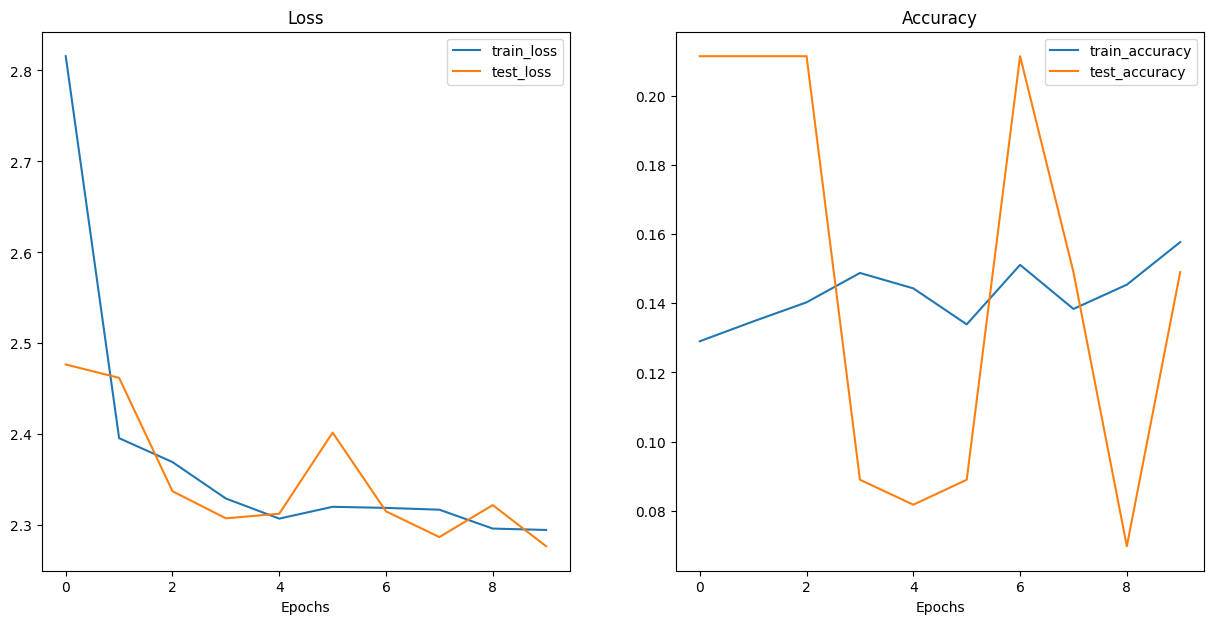

In [150]:
plot_loss_curves(results=results)

## 9. Using a pretrained ViT from `torchvision.models`

Generally, in deep learning if you can use a pretrained model from a large dataset on your own problem, it's often a good place to start.

If you can find a pretrained model and use transfer learning, give it a go, it often achieves great results with little data.

### 9.1 Why use a pretrained model?
* Sometime data is limited
* Limited training resources
* Get better results faster (sometimes)...

### 9.2 Getting a pretrained ViT model and creating a feature extractor

In [62]:
# Get pretrained weights for ViT-Base
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT # "DEFAULT" means best available

# 2. Setup a ViT model instance with pretrained weights
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

# 3. Freeze the base parameters
for parameter in pretrained_vit.parameters():
    parameter.requires_grad = False

# Update the classifier head
set_seeds()
pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(class_names)).to(device)

In [63]:
from torchinfo import summary

summary(model=pretrained_vit,
        input_size=(1, 3, 224, 224), # (batch_size, color_channels, height, width)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"] # get an output of each of the variables name
        )

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 10]              768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

### 9.3 Preparing data for the pretrained ViT model

Remember, if you're going to use a pretrained model, it's generally important to **ensure your own custom data is transformed/formatted in the same way the data the original model was trained on.**

In [64]:
# Get automatic transforms from pretrained ViT weights
pretrained_vit_transforms = pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [65]:
# Setup dataloaders
train_dataloader_pretrained, test_dataloader_pretrained, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                                     test_dir=test_dir,
                                                                                                     transform=pretrained_vit_transforms,
                                                                                                     batch_size=32) # Could set a higher batch size because we're using a pretrained model(because 
                                                                                                                    # in pretrained we don't have much weight updates(only for linear weight update)), such as here: https://arxiv.org/abs/2205.01580 (there are other improvements there too...)


### 9.4 Train feature extractor ViT model

As before we'll use the Adam optimizer (`torch.optim.Adam()`) with a learning rate of `1e-3` and `torch.nn.CrossEntropyLoss()` as the loss function.

In [66]:
# Create optimizer and loss function
optimizer = torch.optim.Adam(params=pretrained_vit.parameters(),
                             lr=1e-3,
                            #  weight_decay=0.03
                             )

loss_fn = torch.nn.CrossEntropyLoss()

# Train the classifier head of the pretrained ViT
set_seeds()
pretrained_vit_results = engine.train(model=pretrained_vit,
                                      train_dataloader=train_dataloader_pretrained,
                                      test_dataloader=test_dataloader_pretrained,
                                      optimizer=optimizer,
                                      loss_fn=loss_fn,
                                      epochs=10,
                                      device=device)

 10%|█         | 1/10 [03:39<32:54, 219.38s/it]

Epoch: 1 | train_loss: 1.4510 | train_acc: 0.5872 | test_loss: 0.9776 | test_acc: 0.7188


 20%|██        | 2/10 [06:23<24:53, 186.74s/it]

Epoch: 2 | train_loss: 0.7717 | train_acc: 0.7906 | test_loss: 0.7448 | test_acc: 0.8101


 30%|███       | 3/10 [09:07<20:35, 176.46s/it]

...

Epoch: 8 | train_loss: 0.2396 | train_acc: 0.9643 | test_loss: 0.4057 | test_acc: 0.8870


 90%|█████████ | 9/10 [25:42<02:46, 166.81s/it]

Epoch: 9 | train_loss: 0.2137 | train_acc: 0.9739 | test_loss: 0.3939 | test_acc: 0.8894


100%|██████████| 10/10 [28:28<00:00, 170.82s/it]

Epoch: 10 | train_loss: 0.1899 | train_acc: 0.9745 | test_loss: 0.3778 | test_acc: 0.8894


### 9.5 Plot feature extractor Pre-trianed ViT model loss curves

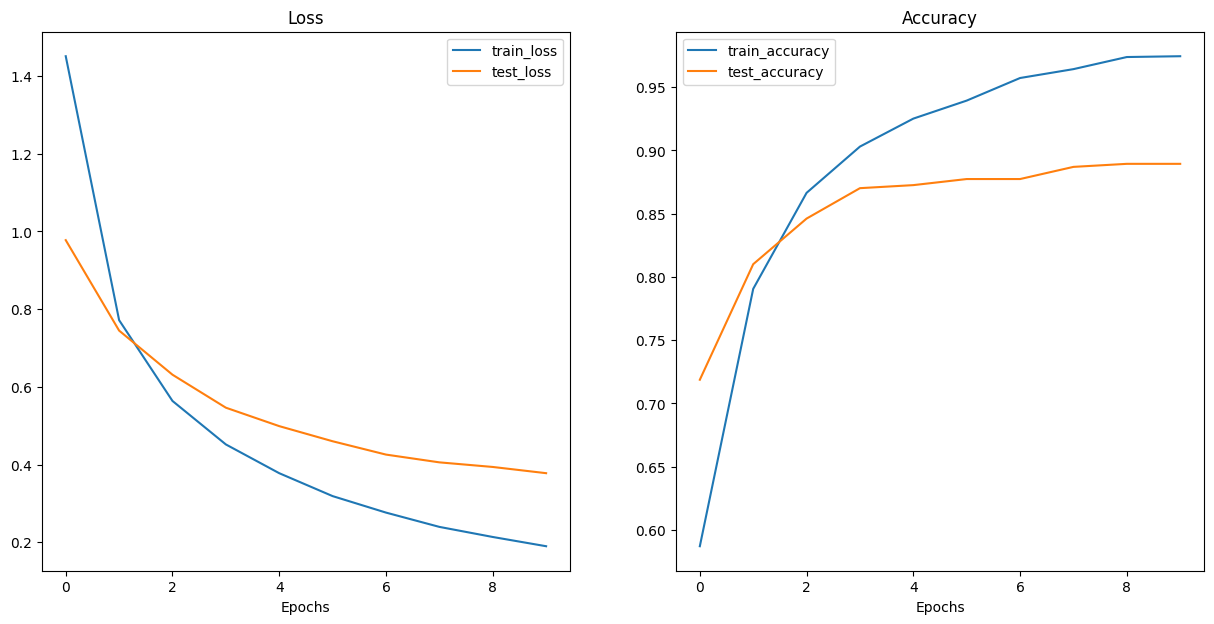

In [67]:
plot_loss_curves(results=pretrained_vit_results)

### 9.6 Save our best performing ViT model

In [68]:
# Save the model
from utils.saving import save_model
save_model(model=pretrained_vit,
           target_dir="models",
           model_name="pretrained_vit_feature_extractor_bishnupur.pth")

[INFO] Saving model to: models/pretrained_vit_feature_extractor_bishnupur.pth


In [69]:
from pathlib import Path

# Get the model size in bytes then convert to megabytes
pretrained_vit_model_size = Path("models/pretrained_vit_feature_extractor_bishnupur.pth").stat().st_size // (1024*1024) # division converts bytes to megabytes (roughly)
print(f"Pretrained ViT feature extractor model size: {pretrained_vit_model_size} MB")

Pretrained ViT feature extractor model size: 327 MB


Pretrained ViT model size (327 MB) is ~11x larger than EfficientNetB2 model (29 MB).

Perhaps the larger model size might cause when we go to deploy it (e.g. hard to deploy such a larger file/might not make predictions as fast as smaller model).

## 10.Make predictions on a custom image

In [80]:
import os
import random

# Setup custom image path
custom_image_path = "../dataset/custom_testing"

# Get all image files from the folder
image_files = [f for f in os.listdir(custom_image_path) 
               if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp"))]

# Pick one random image
if image_files:
    random_image = random.choice(image_files)
    random_image_path = os.path.join(custom_image_path, random_image)
    print("Selected image:", random_image_path)
else:
    print("No images found in folder!")

Selected image: ../dataset/custom_testing/jor_bangla.png


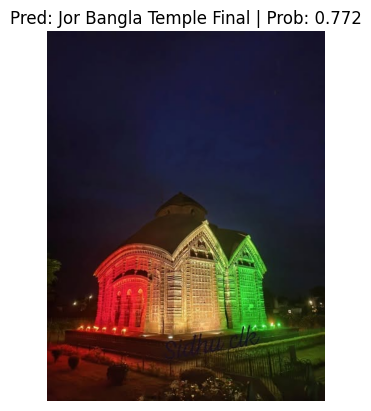

In [81]:
from utils.predictions import pred_and_plot_image

# Predict on custom image
pred_and_plot_image(model=pretrained_vit,
                    image_path=random_image_path,
                    class_names=class_names)